### 5.1. Question 1: The 25-Year "Educational Shield" Trend against Adolescent Fertility

**Analytical Objective:** This section investigates the evolutionary trend over 25 years (2000-2024) to see how expanding female access to higher education correlates with the adolescent fertility rate. Early motherhood is a primary demographic barrier that prevents women from developing advanced skills. By observing the time-series data across 6 representative countries, we aim to prove whether a persistent increase in tertiary education acts as a long-term shield against early pregnancy.

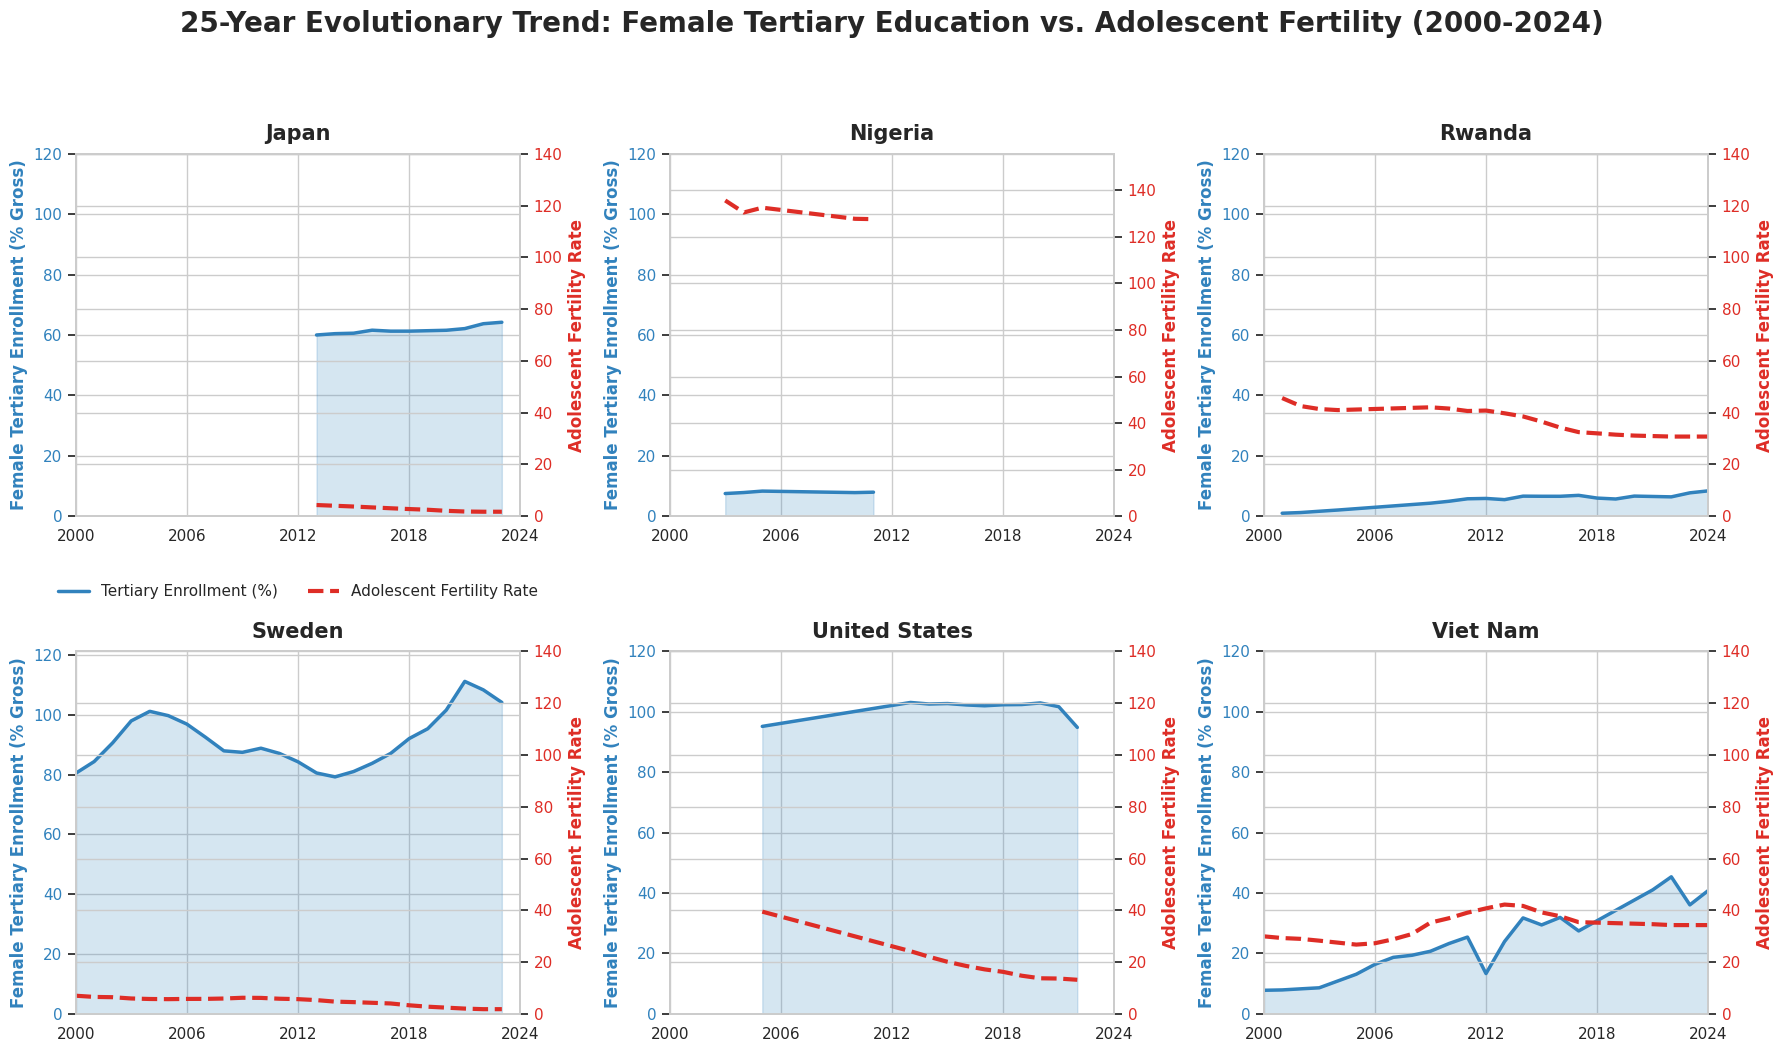

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt tham số đồ họa
plt.rcParams['figure.figsize'] = (18, 10)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

# 1. Đọc và làm sạch dữ liệu từ file CSV
DATA_PATH = 'data3/dataset.csv' # Nhớ check lại đường dẫn
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

INDICATORS = {
    'SE.TER.ENRR.FE': 'Tertiary_Edu',
    'SP.ADO.TFRT': 'Adolescent_Fertility'
}

q1_df = df_raw[df_raw['Series Code'].isin(INDICATORS.keys())].copy()
year_cols = [c for c in q1_df.columns if c.startswith('20') and (c.endswith(']') or len(c) == 4 or '[' in c)]

q1_long = q1_df.melt(id_vars=['Country Name', 'Country Code', 'Series Code'],
                     value_vars=year_cols, var_name='YearRaw', value_name='Value')

q1_long['Year'] = q1_long['YearRaw'].astype(str).str.extract(r'(\d{4})').astype(int)
q1_long['Value'] = pd.to_numeric(q1_long['Value'], errors='coerce')

# Xóa trùng lặp và tạo Pivot Table cho chuỗi 25 năm
q1_long = q1_long.drop_duplicates(subset=['Country Name', 'Country Code', 'Series Code', 'Year'])
pivot_df = q1_long.pivot_table(index=['Country Name', 'Year'], 
                               columns='Series Code', 
                               values='Value', aggfunc='mean').reset_index()

pivot_df.rename(columns=INDICATORS, inplace=True)
pivot_df = pivot_df.dropna(subset=['Tertiary_Edu', 'Adolescent_Fertility'])

# 2. Thiết lập Lưới 6 Subplots (2 hàng x 3 cột)
countries = pivot_df['Country Name'].unique()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('25-Year Evolutionary Trend: Female Tertiary Education vs. Adolescent Fertility (2000-2024)', 
             fontsize=20, fontweight='bold', y=1.05)
axes = axes.flatten()

color_edu = '#3182bd'  # Xanh dương cho Giáo dục
color_fert = '#de2d26' # Đỏ cho Tỷ lệ đẻ sớm

# 3. Vẽ biểu đồ cho từng quốc gia
for i, country in enumerate(countries):
    ax1 = axes[i]
    country_data = pivot_df[pivot_df['Country Name'] == country].sort_values('Year')
    
    # Vẽ phần diện tích và đường cho Giáo dục (Trục trái)
    ax1.fill_between(country_data['Year'], country_data['Tertiary_Edu'], color=color_edu, alpha=0.2)
    line1, = ax1.plot(country_data['Year'], country_data['Tertiary_Edu'], color=color_edu, linewidth=2.5, label='Tertiary Enrollment (%)')
    ax1.set_title(country, fontsize=15, fontweight='bold', pad=10)
    ax1.set_ylabel('Female Tertiary Enrollment (% Gross)', color=color_edu, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_edu)
    ax1.set_ylim(0, max(120, country_data['Tertiary_Edu'].max() + 10))
    ax1.set_xlim(2000, 2024)
    ax1.set_xticks([2000, 2006, 2012, 2018, 2024])
    
    # Vẽ đường cho Tỷ lệ sinh (Trục phải)
    ax2 = ax1.twinx()
    line2, = ax2.plot(country_data['Year'], country_data['Adolescent_Fertility'], color=color_fert, linewidth=3, linestyle='--', label='Adolescent Fertility Rate')
    ax2.set_ylabel('Adolescent Fertility Rate', color=color_fert, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_fert)
    ax2.set_ylim(0, max(140, country_data['Adolescent_Fertility'].max() + 20))
    
    # Gắn Legend cho ô đầu tiên để làm mẫu
    if i == 0:
        ax1.legend(handles=[line1, line2], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

**Observations & Conclusions over the 25-Year Trend:**

Analyzing the 6-country grid from 2000 to 2024 reveals three distinct demographic-educational profiles:

* **1. The "Fully Shielded" Developed Nations (Sweden, Japan):** In these countries, female tertiary enrollment has been saturated at very high levels (ranging from 60% in Japan to over 100% in Sweden). Consequently, their adolescent fertility rates (red dashed lines) are completely flattened near the bottom (below 10 births per 1,000 women). The "educational shield" here is fully active and perfectly stable over decades.
* **2. The Active Transition (United States, Viet Nam):** The United States showcases a beautiful active decline: while education remains fully saturated (near 100%), its teen pregnancy rate steadily plunges from ~40 down to ~15. Viet Nam presents the most dynamic "X-shaped" volatility. Its female tertiary education experienced a massive, albeit fluctuating, surge (from under 10% to over 40%), which is actively fighting to push the adolescent fertility rate back down after a cultural spike in the mid-2010s.
* **3. The Developing Challenge (Rwanda, Nigeria):** These nations highlight the danger zone. Rwanda shows a slow but commendable climb in female university enrollment (from nearly 0% to ~10%), which mirrors a steady decline in early pregnancies (from ~40 down to ~30). Nigeria, on the other hand, illustrates the starkest contrast: stagnated tertiary enrollment (below 10%) correlates directly with astronomical adolescent fertility rates (consistently above 100+). 
* **Data Note:** *The visible gaps in the trendlines for Nigeria (post-2011), Japan (pre-2013), and the US are due to standard missing reporting years in the World Bank database. However, they do not invalidate the overarching macro-trend.*
* **Final Conclusion:** The time-series data undeniably confirms the hypothesis. Expanding access to higher education for females is not a short-term fix, but a long-term prerequisite for eradicating early pregnancies and unlocking female human capital globally.